# Chapter 19 - Microstructural Features

## Preparation

In [1]:

import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.regression.linear_model import OLS

from utils.data_paths import ES_EVENTS, ES_TRADES
from utils.microstructure import (
    tick_rule,
    roll_model,
    high_low_volatility,
    close_to_close_volatility,
    make_time_bars,
    make_dollar_bars,
    corwin_schultz_spread,
    corwin_schultz_implied_volatility,
    kyle_lambda,
    amihud_lambda,
)

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16, 6

In [2]:
df = pd.read_parquet(ES_EVENTS)

In [3]:
trades = pd.read_parquet(ES_TRADES)

In [4]:
# Reuse the prepared Databento trades instead of a second vendor CSV.
es_trades = (
    trades[["ts_event", "price", "size"]]
    .rename(columns={"size": "volume"})
    .dropna(subset=["ts_event", "price", "volume"])
    .sort_values("ts_event")
    .set_index("ts_event")
)

# ES futures are quoted in index points with a $50 multiplier.
es_trades["dollar_vol"] = es_trades["price"] * es_trades["volume"] * 50
es_trades = es_trades[["price", "volume", "dollar_vol"]]


In [5]:
df.head()

,ts_recv,ts_event,rtype,publisher_id,instrument_id,action,side,depth,price,size,...,spread,spread_ticks,midpoint,book_imbalance,microprice,microprice_minus_mid,order_count_imbalance,ts_send,feed_latency_ns,bbo_changed
0,2023-11-01 14:30:00.002571318+00:00,2023-11-01 14:30:00.002467691+00:00,1,1,314863,A,B,0,4241.00,7,...,0.25,1.0,4241.125,-0.090909,4241.113636,-0.011364,-0.173913,2023-11-01 14:30:00.002555241+00:00,16077,True
1,2023-11-01 14:30:00.002664781+00:00,2023-11-01 14:30:00.002574269+00:00,1,1,314863,A,B,0,4241.00,5,...,0.25,1.0,4241.125,-0.038462,4241.120192,-0.004808,-0.148936,2023-11-01 14:30:00.002649319+00:00,15462,True
2,2023-11-01 14:30:00.002678712+00:00,2023-11-01 14:30:00.002586051+00:00,1,1,314863,A,B,0,4241.00,1,...,0.25,1.0,4241.125,-0.028571,4241.121429,-0.003571,-0.125000,2023-11-01 14:30:00.002665072+00:00,13640,True
3,2023-11-01 14:30:00.003316179+00:00,2023-11-01 14:30:00.003226289+00:00,1,1,314863,A,B,0,4241.00,10,...,0.25,1.0,4241.125,0.060870,4241.132609,0.007609,-0.102041,2023-11-01 14:30:00.003300413+00:00,15766,True
4,2023-11-01 14:30:00.003324617+00:00,2023-11-01 14:30:00.003240339+00:00,1,1,314863,C,A,0,4241.25,10,...,0.25,1.0,4241.125,0.161905,4241.145238,0.020238,-0.083333,2023-11-01 14:30:00.003311148+00:00,13469,True


In [6]:

if "trade_sign" not in trades.columns:
    trades["trade_sign"] = trades["side"].map(
        {"B": 1, "A": -1, "N": 0}
    ).astype("int8")

trades[["ts_event", "side", "price", "size", "bid_px_00", "ask_px_00", "trade_sign"]].head()


,ts_event,side,price,size,bid_px_00,ask_px_00,trade_sign
0,2023-11-01 14:30:00.023837223+00:00,B,4241.25,9,4241.0,4241.25,1
1,2023-11-01 14:30:00.023851335+00:00,B,4241.25,12,4241.0,4241.25,1
2,2023-11-01 14:30:00.024083395+00:00,B,4241.25,4,4241.0,4241.25,1
3,2023-11-01 14:30:00.024091453+00:00,B,4241.25,2,4241.0,4241.25,1
4,2023-11-01 14:30:00.024110229+00:00,B,4241.25,5,4241.0,4241.25,1


In [7]:
df["action"].value_counts()

action
A    2493604
C    2098415
T     347722
M     190948
Name: count, dtype: int64

In [8]:
df.columns

Index(['ts_recv', 'ts_event', 'rtype', 'publisher_id', 'instrument_id',
       'action', 'side', 'depth', 'price', 'size', 'flags', 'ts_in_delta',
       'sequence', 'bid_px_00', 'ask_px_00', 'bid_sz_00', 'ask_sz_00',
       'bid_ct_00', 'ask_ct_00', 'symbol', 'spread', 'spread_ticks',
       'midpoint', 'book_imbalance', 'microprice', 'microprice_minus_mid',
       'order_count_imbalance', 'ts_send', 'feed_latency_ns', 'bbo_changed'],
      dtype='str')

<Axes: xlabel='ts_event'>

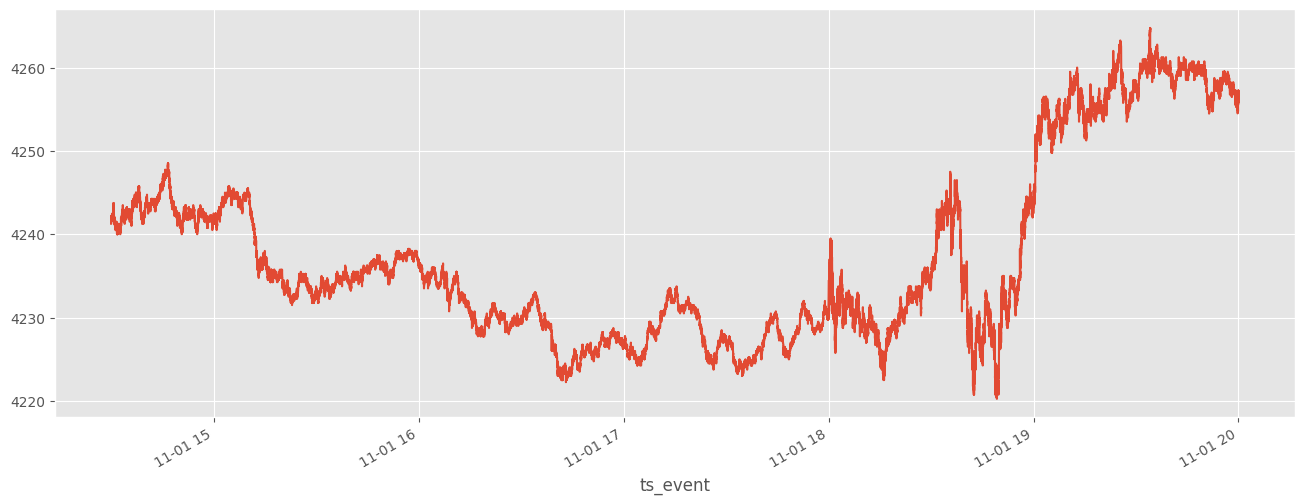

In [9]:

trades.set_index("ts_event")["price"].plot()


## 1. From a time series of E-mini S&P 500 futures tick data,

### a. Apply the tick rule to derive the series of trade signs.

In [10]:

trade_signs = tick_rule(trades, "price")
tick_rule_comparison = trades.copy()
tick_rule_comparison["tick_rule_sign"] = trade_signs
tick_rule_comparison["tick_rule_valid"] = tick_rule_comparison["tick_rule_sign"] != 0

num_neg = (trade_signs < 0).sum()
num_pos = (trade_signs > 0).sum()
num_zero = (trade_signs == 0).sum()
print(f"Number of negative trade signs: {num_neg:,}")
print(f"Number of positive trade signs: {num_pos:,}")
print(f"Number of neutral trade signs: {num_zero:,}")


Number of negative trade signs: 177,222
Number of positive trade signs: 170,470
Number of neutral trade signs: 30


### b. Compare to the aggressor's side, as provided by the CME (FIX tag 5797).  What is the accuracy of the tick rule?

In [11]:

cme_provided_side = tick_rule_comparison["trade_sign"]
valid_tick_rule = tick_rule_comparison["tick_rule_valid"]

print(f"CME-provided trade signs: {cme_provided_side.notna().sum():,}")
print(f"Tick-rule signs used in accuracy: {valid_tick_rule.sum():,}")


CME-provided trade signs: 347,722
Tick-rule signs used in accuracy: 347,692


In [12]:

accuracy = (
    tick_rule_comparison.loc[valid_tick_rule, "tick_rule_sign"]
    == cme_provided_side.loc[valid_tick_rule]
).mean()

print(f"Accuracy of the tick rule on trade events: {accuracy:.2%}")


Accuracy of the tick rule on trade events: 66.97%


### c. Select the cases where FIX tag 5797 disagrees with the tick rule.

In [13]:

disagree_mask = valid_tick_rule & (
    tick_rule_comparison["trade_sign"] != tick_rule_comparison["tick_rule_sign"]
)
disagree_idx = tick_rule_comparison.index[disagree_mask]

disagree_sample = tick_rule_comparison.loc[disagree_idx].sample(
    min(20, len(disagree_idx)),
    random_state=42,
)

print("Disagree samples:")
disagree_sample[
    [
        "price",
        "trade_sign",
        "tick_rule_sign",
        "bid_px_00",
        "ask_px_00",
        "price_minus_mid_ticks",
        "spread_ticks",
        "size",
    ]
]


Disagree samples:


,price,trade_sign,tick_rule_sign,bid_px_00,ask_px_00,price_minus_mid_ticks,spread_ticks,size
104520,4224.50,1,-1,4224.25,4224.50,0.5,1.0,2
190199,4235.25,-1,1,4235.25,4235.50,-0.5,1.0,1
50781,4234.50,-1,1,4234.50,4234.75,-0.5,1.0,2
141729,4231.50,1,-1,4231.25,4231.50,0.5,1.0,2
5434,4242.25,1,-1,4242.00,4242.25,0.5,1.0,2
233138,4229.75,1,-1,4229.50,4229.75,0.5,1.0,1
119436,4223.75,-1,1,4223.75,4224.00,-0.5,1.0,7
217846,4227.50,1,-1,4227.25,4227.50,0.5,1.0,1
54677,4234.50,-1,1,4234.50,4234.75,-0.5,1.0,2
27074,4241.50,-1,1,4241.50,4241.75,-0.5,1.0,1


In [14]:

print("Disagreement diagnostics:")
tick_rule_comparison.loc[
    disagree_idx,
    ["price_minus_mid_ticks", "spread_ticks", "size", "book_imbalance"],
].describe()


Disagreement diagnostics:


,price_minus_mid_ticks,spread_ticks,size,book_imbalance
count,114855.000000,114855.000000,114855.000000,114855.000000
mean,0.026729,1.000723,2.891742,0.037380
std,0.500130,0.042652,4.101278,0.759966
min,-3.000000,1.000000,1.000000,-0.996441
25%,-0.500000,1.000000,1.000000,-0.779817
50%,0.500000,1.000000,1.000000,0.244444
75%,0.500000,1.000000,3.000000,0.806452
max,3.000000,6.000000,140.000000,0.996540


In [15]:

agree_mask = valid_tick_rule & (
    tick_rule_comparison["trade_sign"] == tick_rule_comparison["tick_rule_sign"]
)
agree_idx = tick_rule_comparison.index[agree_mask]

agree_sample = tick_rule_comparison.loc[agree_idx].sample(
    min(20, len(agree_idx)),
    random_state=42,
)

print("Agree samples:")
agree_sample[
    [
        "price",
        "trade_sign",
        "tick_rule_sign",
        "bid_px_00",
        "ask_px_00",
        "price_minus_mid_ticks",
        "spread_ticks",
        "size",
    ]
]


Agree samples:


,price,trade_sign,tick_rule_sign,bid_px_00,ask_px_00,price_minus_mid_ticks,spread_ticks,size
143970,4229.25,1,1,4229.00,4229.25,0.5,1.0,4
281322,4254.00,-1,-1,4254.00,4254.25,-0.5,1.0,1
118730,4225.25,-1,-1,4225.25,4225.50,-0.5,1.0,1
62563,4236.25,-1,-1,4236.25,4236.50,-0.5,1.0,3
75766,4233.25,-1,-1,4233.25,4233.50,-0.5,1.0,1
79146,4229.25,1,1,4229.00,4229.25,0.5,1.0,5
333296,4257.50,-1,-1,4257.50,4257.75,-0.5,1.0,1
145997,4231.00,-1,-1,4231.00,4231.25,-0.5,1.0,1
211363,4226.75,-1,-1,4226.75,4227.00,-0.5,1.0,1
119608,4224.25,-1,-1,4224.25,4224.50,-0.5,1.0,1


In [16]:

print("Agreement diagnostics:")
tick_rule_comparison.loc[
    agree_idx,
    ["price_minus_mid_ticks", "spread_ticks", "size", "book_imbalance"],
].describe()


Agreement diagnostics:


,price_minus_mid_ticks,spread_ticks,size,book_imbalance
count,232837.000000,232837.000000,232837.000000,232837.000000
mean,0.021809,1.013688,3.951034,-0.004565
std,0.805719,0.150779,8.087081,0.639322
min,-18.500000,1.000000,1.000000,-0.996460
25%,-0.500000,1.000000,1.000000,-0.610390
50%,-0.500000,1.000000,1.000000,-0.015385
75%,0.500000,1.000000,4.000000,0.608696
max,15.000000,11.000000,456.000000,0.996383


#### i. Can you see anything distinct that would explain the disagreement?


The comparison must be restricted to trade events. Add, cancel, and modify messages carry book-side information, not an aggressor trade sign, so using them explains the earlier low accuracy and the misleading cancellation-rate conclusion. The remaining disagreements are true trade-classification disagreements: the tick rule uses only the direction of the last price change, while FIX tag 5797 is the exchange-provided aggressor side.


#### ii. Are these disagreements associated with large price jumps? Or high  cancelation rates? Or thin quoted sizes?

In [17]:

trade_diagnostics = tick_rule_comparison.copy()
trade_diagnostics["disagrees"] = disagree_mask
trade_diagnostics["abs_price_change_ticks"] = (
    trade_diagnostics["price"].diff().abs() / 0.25
)
trade_diagnostics["quoted_size"] = (
    trade_diagnostics["bid_sz_00"] + trade_diagnostics["ask_sz_00"]
)

trade_diagnostics.groupby("disagrees")[
    ["abs_price_change_ticks", "spread_ticks", "quoted_size", "size"]
].describe()


abs_price_change_ticks                                          \
                           count      mean       std  min  25%  50%  75%   
disagrees                                                                  
False                   232866.0  0.214377  0.418760  0.0  0.0  0.0  0.0   
True                    114855.0  0.006843  0.094636  0.0  0.0  0.0  0.0   

                spread_ticks            ... quoted_size             size  \
            max        count      mean  ...         75%    max     count   
disagrees                               ...                                
False      11.0     232867.0  1.013686  ...        91.0  929.0  232867.0   
True        7.0     114855.0  1.000723  ...        89.0  774.0  114855.0   

                                                          
               mean       std  min  25%  50%  75%    max  
disagrees                                                 
False      3.951097  8.086766  1.0  1.0  1.0  4.0  456.0  
True       2.891742  4.101278  1.0  1.0  1.0  3.0  140.0  

[2 rows x 32 columns]

In [18]:

quote_size_median = trade_diagnostics["quoted_size"].median()
thin_quotes = trade_diagnostics["quoted_size"] <= quote_size_median

pd.crosstab(
    thin_quotes.rename("thin_quote"),
    trade_diagnostics["disagrees"],
    normalize="index",
)


disagrees,False,True
thin_quote,,
False,0.668333,0.331667
True,0.671043,0.328957



Cancellation rates are not part of this trade-only comparison. The diagnostics above compare disagreement rates against price jumps, spreads, and quoted size; thin quote conditions should be assessed from the contemporaneous bid and ask sizes rather than from all order-book events.


#### iii. Are these disagreements more likely to occur during periods of high or low market activity?


Use per-minute trade count and traded notional as market-activity proxies. Order-book imbalance is a state variable, not a direct activity measure, but it is still useful to compare alongside activity.


In [19]:

trade_activity = (
    trades.set_index("ts_event")
    .resample("1min")
    .agg(
        trade_count=("price", "size"),
        traded_notional=("trade_notional", "sum"),
    )
)

trade_diagnostics["minute"] = pd.to_datetime(
    trade_diagnostics["ts_event"]
).dt.floor("min")
trade_diagnostics = trade_diagnostics.join(trade_activity, on="minute")


In [20]:

print("Market activity on agree samples:")
trade_diagnostics.loc[
    agree_mask,
    ["trade_count", "traded_notional", "book_imbalance"],
].describe()


Market activity on agree samples:


,trade_count,traded_notional,book_imbalance
count,232837.000000,2.328370e+05,232837.000000
mean,1818.906656,1.480777e+09,-0.004565
std,1383.945587,1.781606e+09,0.639322
min,204.000000,1.661899e+08,-0.996460
25%,738.000000,5.800557e+08,-0.610390
50%,1354.000000,9.905990e+08,-0.015385
75%,2501.000000,1.877784e+09,0.608696
max,6706.000000,1.218299e+10,0.996383


In [21]:

print("Market activity on disagree samples:")
trade_diagnostics.loc[
    disagree_mask,
    ["trade_count", "traded_notional", "book_imbalance"],
].describe()


Market activity on disagree samples:


,trade_count,traded_notional,book_imbalance
count,114855.000000,1.148550e+05,114855.000000
mean,1795.093805,1.422089e+09,0.037380
std,1339.470324,1.630298e+09,0.759966
min,204.000000,1.661899e+08,-0.996441
25%,764.000000,5.915954e+08,-0.779817
50%,1362.000000,9.905990e+08,0.244444
75%,2458.000000,1.689063e+09,0.806452
max,6706.000000,1.218299e+10,0.996540


We can see that all three aspects in disagreement are lower than that of the agreement, so we can claim that the disagreement happens in low market activity.


## 2. Compute the Roll model on the time series of E-mini S&P 500 futures tick data.

### a. What are the estimated values of $\sigma_u^2$ and $c$?


Let $\gamma = COV[\Delta p_t, \Delta p_{t-1}]$.

$$c = \sqrt{max\{0, -\gamma\}}$$

$$\sigma_u^2 = VAR[\Delta p_t] + 2\gamma$$

In [22]:

roll_estimates = roll_model(es_trades["price"])

print(f"Cov[delta p_t, delta p_t-1]: {roll_estimates['price_diff_lag_cov']:.6f}")
print(f"Estimated c (half-spread, index points): {roll_estimates['c']:.6f}")
print(f"Estimated Roll spread 2c: {roll_estimates['spread']:.6f}")
print(f"Estimated sigma_u^2: {roll_estimates['sigma_u_2']:.6f}")


Cov[delta p_t, delta p_t-1]: -0.001190
Estimated c (half-spread, index points): 0.034499
Estimated Roll spread 2c: 0.068998
Estimated sigma_u^2: 0.001162


### b. Knowing that this contract is one of the most liquid products in the world, and that it trades at the tightest possible bid-ask spread, are these values in line with your expectations?


The Roll estimate should be judged against the ES tick size of 0.25 index points. Because ES is highly liquid, a small implied spread is expected, but the estimate can still differ from the minimum tick when the Roll assumptions are violated by clustered trades, price discreteness, and intraday volatility.


## 3. Compute the high-low volatility estimator (Section19.3.3.) on E-mini S&P 500 futures:

$$\sigma = \sqrt{\frac{1}{4N \log{2}} \sum_{t=1}^N [\log{\frac{H_t}{L_t}}]^2}$$

In [23]:

def volatility_summary(bars):
    return pd.Series(
        {
            "num_bars": len(bars),
            "high_low_volatility": high_low_volatility(
                bars["price_high"],
                bars["price_low"],
            ),
            "close_to_close_log_volatility": close_to_close_volatility(
                bars["price"],
            ),
        }
    )


### a. Using weekly values, how does this differ from the standard deviation of  close-to-close returns?

In [24]:

active_daily_dollar_volume = es_trades["dollar_vol"].resample("1D").sum()
active_daily_dollar_volume = active_daily_dollar_volume[active_daily_dollar_volume > 0]
active_daily_dollar_volume.describe()


count    1.800000e+01
mean     1.012872e+11
std      6.224608e+10
min      2.532328e+09
25%      6.582157e+10
50%      1.141154e+11
75%      1.434472e+11
max      2.064276e+11
Name: dollar_vol, dtype: float64

In [25]:

weekly_bars = make_time_bars(
    es_trades,
    "W",
    price_col="price",
    volume_col="volume",
    dollar_col="dollar_vol",
)

weekly_volatility = volatility_summary(weekly_bars)
print(f"Weekly bars: {len(weekly_bars)}")
weekly_volatility


Weekly bars: 4


num_bars                         4.000000
high_low_volatility              0.012550
close_to_close_log_volatility    0.011948
dtype: float64

### b. Using daily values, how does this differ from the standard deviation of close-to-close returns?

In [26]:

daily_bars = make_time_bars(
    es_trades,
    "1D",
    price_col="price",
    volume_col="volume",
    dollar_col="dollar_vol",
)

daily_volatility = volatility_summary(daily_bars)
print(f"Daily bars: {len(daily_bars)}")
daily_volatility


Daily bars: 18


num_bars                         18.000000
high_low_volatility               0.005615
close_to_close_log_volatility     0.005797
dtype: float64

### c. Using dollar bars, for an average of 50 bars per day, how does this differ  from the standard deviation of close-to-close returns?

In [27]:

dollar_threshold = active_daily_dollar_volume.mean() / 50
es_dollar_bars = make_dollar_bars(
    es_trades,
    dollar_threshold,
    price_col="price",
    dollar_col="dollar_vol",
)
dollar_bars_per_day = es_dollar_bars["price"].resample("1D").size()
active_dollar_bars_per_day = dollar_bars_per_day[dollar_bars_per_day > 0]

dollar_bar_volatility = volatility_summary(es_dollar_bars)
print(f"Dollar threshold: ${dollar_threshold:,.0f}")
print(f"Average dollar bars per active day: {active_dollar_bars_per_day.mean():.2f}")
dollar_bar_volatility


Dollar threshold: $2,025,744,624
Average dollar bars per active day: 50.00


num_bars                         900.000000
high_low_volatility                0.000781
close_to_close_log_volatility      0.000812
dtype: float64

## 4. Apply the Corwin-Schultz estimator to a daily series of E-mini S&P 500  futures.

### a. What is the expected bid-ask spread?

In [28]:

expected_spread, alpha, beta, gamma = corwin_schultz_spread(
    daily_bars,
    1,
    "price_high",
    "price_low",
)

print(f"Alpha: {alpha.mean():.6f}")
print(f"Beta: {beta.mean():.6f}")
print(f"Gamma: {gamma.mean():.6f}")
print(f"Expected bid-ask spread by Corwin-Schultz: {expected_spread['spread'].mean():.6f}")


Alpha: 0.001682
Beta: 0.000178
Gamma: 0.000194
Expected bid-ask spread by Corwin-Schultz: 0.001682


### b. What is the implied volatility?

In [29]:

implied_volatility = corwin_schultz_implied_volatility(beta, gamma)

print(f"Implied volatility by Corwin-Schultz: {implied_volatility.mean():.6f}")


Implied volatility by Corwin-Schultz: 0.006410


### c. Are these estimates consistent with the earlier results, from exercises 2  and 3?


Corwin-Schultz uses daily high-low ranges, Roll uses serial covariance in trade-price changes, and the high-low estimator measures volatility rather than spread. They should be directionally consistent for a liquid market, but they need not match numerically because they estimate different objects from different moments of the price process.


## 5. Compute Kyle's lambda from:

$$\Delta p_t = \lambda(b_tV_t) + \epsilon_t$$

### a. tick data

In [30]:
kyle_inputs = trades.copy()
kyle_inputs["returns"] = kyle_inputs["price"].diff()
kyle_inputs.dropna(inplace=True)

kyle_lamb = kyle_lambda(kyle_inputs["returns"], kyle_inputs["trade_sign"], kyle_inputs["size"])
kyle_lamb

np.float64(0.003506360257907263)

### b. a time series of dollar bars on E-mini S&P 500 futures, where

#### i. $b_t$ is the volume-weighted average of the trade signs.

#### ii. $V_t$ is the sum of the volumes in that bar.

#### iii. $\Delta p_t$ is the change in price between two consecutive bars.

In [31]:
price_col = "price"
dollar_col = "trade_notional"
dollar_threshold = trades["trade_notional"].mean() * 5
aggresor_col = "trade_sign"
volume_col = "size"

data = trades[[price_col, dollar_col, aggresor_col, volume_col]].dropna().copy()
data = data[(data[price_col] > 0) & (data[dollar_col] > 0)]

data["vol_weighted_aggressor"] = data[aggresor_col] * data[volume_col]
data["hasbrouck_inner_term"] = data[aggresor_col] * np.sqrt(data[dollar_col])

data = data.sort_index()
bar_ids = []
bar_id = 0
bar_dollars = 0.0
for dollar_value in data[dollar_col].to_numpy():
    bar_dollars += dollar_value
    bar_ids.append(bar_id)
    if bar_dollars >= dollar_threshold:
        bar_id += 1
        bar_dollars = 0.0
data["_bar_id"] = bar_ids

grouped = data.groupby("_bar_id", sort=True)
trade_dollar_bar = grouped.agg(
    price_open=(price_col, "first"),
    price_high=(price_col, "max"),
    price_low=(price_col, "min"),
    price=(price_col, "last"),
    dollar_vol=(dollar_col, "sum"),
    tick_count=(price_col, "size"),
    volume = (volume_col, "sum"),
    trade_sign = ("vol_weighted_aggressor", "mean"),
    hasbrouck_inner_term = ("hasbrouck_inner_term", "sum"),
)
trade_dollar_bar.insert(0, "bar_id", trade_dollar_bar.index.to_numpy())
trade_dollar_bar.index.name = "bar_id"

if isinstance(data.index, pd.DatetimeIndex):
    trade_dollar_bar["start_time"] = grouped.apply(lambda group: group.index[0])
    trade_dollar_bar["end_time"] = grouped.apply(lambda group: group.index[-1])
    trade_dollar_bar = trade_dollar_bar.set_index("end_time", drop=False)

trade_dollar_bar["log_returns"] = np.log(trade_dollar_bar["price"]).diff()
trade_dollar_bar["returns"] = trade_dollar_bar["price"].diff()
trade_dollar_bar.dropna(inplace=True)

trade_dollar_bar

,bar_id,price_open,price_high,price_low,price,dollar_vol,tick_count,volume,trade_sign,hasbrouck_inner_term,log_returns,returns
bar_id,,,,,,,,,,,,
1,1,4241.25,4241.25,4241.25,4241.25,7210125.0,4,34,-3.000000,393.476320,0.000000,0.00
2,2,4241.25,4241.25,4241.25,4241.25,5089500.0,4,24,-0.500000,-138.990669,0.000000,0.00
3,3,4241.25,4241.25,4241.25,4241.25,4029187.5,8,19,0.875000,2407.522262,0.000000,0.00
4,4,4241.25,4241.25,4241.25,4241.25,4453312.5,6,21,-1.500000,-4.423853,0.000000,0.00
5,5,4241.25,4241.50,4241.25,4241.50,4453400.0,11,21,1.363636,5132.959768,0.000059,0.25
...,...,...,...,...,...,...,...,...,...,...,...,...
50414,50414,4256.50,4256.50,4256.50,4256.50,3830850.0,6,18,1.000000,468.717005,0.000000,0.00
50415,50415,4256.50,4256.50,4256.50,4256.50,4894975.0,4,23,5.750000,4202.085467,0.000000,0.00
50416,50416,4256.50,4256.75,4256.50,4256.50,6597600.0,4,31,-6.750000,-3176.857710,0.000000,0.00


In [32]:
kyle_lamb_dollar_bar = kyle_lambda(trade_dollar_bar["returns"], trade_dollar_bar["trade_sign"], trade_dollar_bar["volume"])

kyle_lamb_dollar_bar

np.float64(1.5056190257127008e-05)

## 6. Repeat exercise 5, this time applying Hasbrouck's lambda. Are results consistent?

In [ ]:
y = np.array(trade_dollar_bar["log_returns"])
X = np.array(trade_dollar_bar["hasbrouck_inner_term"])
model = OLS(y, X)
results = model.fit()

print(results.summary())

hasbrouck_lamb_dollar_bar = results.params[0]

hasbrouck_lamb_dollar_bar

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.214
Model:                            OLS   Adj. R-squared (uncentered):              0.214
Method:                 Least Squares   F-statistic:                          1.377e+04
Date:                Tue, 14 Jul 2026   Prob (F-statistic):                        0.00
Time:                        14:21:22   Log-Likelihood:                      4.4412e+05
No. Observations:               50418   AIC:                                 -8.882e+05
Df Residuals:                   50417   BIC:                                 -8.882e+05
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

np.float64(6.196045004658448e-09)

## 7. Repeat exercise 5, this time applying Amihud's lambda. Are results consistent?

In [36]:
amihud_lamb_dollar_bar = amihud_lambda(trade_dollar_bar["log_returns"].abs(), trade_dollar_bar["dollar_vol"])

amihud_lamb_dollar_bar

np.float64(3.8749406954324274e-12)

## 8. Form a time series of volume bars on E-mini S&P 500 futures,

### a. Compute the series of VPIN on May 6, 2010 (flash crash).

### b. Plot the series of VPIN and prices. What do you see?

Sadly we do not have the E-mini S&P 500 futures data on May 6, 2010.